# Predicted vs Ground Truth Neural Activity

Compare model predictions against ground truth firing rates for three trained models:

**Mouse data (side-by-side):**
- Model A: `single_session_26872` — with behavior (eye tracker + treadmill)
- Model B: `single_session_26872_no_beh` — without behavior

**Mozaik synthetic data (separate):**
- Model C: `single_session_mozaik_26872_no_beh` — without behavior, 37,500 neurons

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import types
import numpy as np
import matplotlib.pyplot as plt
import torch

# Mock datajoint and gitpython
_dj = types.ModuleType('datajoint')
_dj.config = {}
for sub in ['utils', 'schema', 'schemas', 'fetch']:
    mod = types.ModuleType(f'datajoint.{sub}')
    setattr(_dj, sub, mod)
    sys.modules[f'datajoint.{sub}'] = mod
_dj.utils.to_camel_case = lambda s: s
_dj.schema.Schema = type('Schema', (), {})
_dj.schemas.Schema = type('Schema', (), {})
_dj.fetch.DataJointError = Exception
sys.modules['datajoint'] = _dj

_git = types.ModuleType('git')
_git.Repo = type('Repo', (), {})
_git.cmd = types.ModuleType('git.cmd')
sys.modules['git'] = _git
sys.modules['git.cmd'] = _git.cmd

BASE = '/mnt/vast-nhr/projects/nix00014/goirik/MOZAIK-new'
sys.path.insert(0, f'{BASE}/sensorium/notebooks/model_tutorial/nnfabrik_base')
sys.path.insert(0, f'{BASE}/experanto')
sys.path.insert(0, f'{BASE}/neuralpredictors')
sys.path.insert(0, f'{BASE}/latent_space_model')

from sensorium.models.make_model import make_video_model
from neuralpredictors.training import device_state
from neuralpredictors.measures.np_functions import corr
from experanto.configs import DEFAULT_CONFIG
from experanto.dataloaders import get_multisession_dataloader
from copy import deepcopy
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


## Helper Functions

In [2]:
def load_model(checkpoint_path, core_dict, readout_dict, use_shifter=False,
               shifter_dict=None, shifter_type=None, seed=42):
    """Load a trained model from checkpoint. Extracts data_key and n_neurons automatically."""
    state_dict = torch.load(checkpoint_path, map_location='cpu')
    readout_keys = [k for k in state_dict if k.startswith('readout.')]
    data_key = readout_keys[0].split('.')[1]
    n_neurons = state_dict[f'readout.{data_key}.bias'].shape[0]

    n_neurons_dict = {data_key: n_neurons}
    mean_activity_dict = {data_key: torch.zeros(n_neurons)}

    model = make_video_model(
        None, seed,
        core_dict=core_dict,
        core_type='3D_factorised',
        readout_dict=readout_dict.copy(),
        readout_type='gaussian',
        use_gru=False, gru_dict=None,
        use_shifter=use_shifter,
        shifter_dict=shifter_dict,
        shifter_type=shifter_type,
        deeplake_ds=False,
        n_neurons_dict=n_neurons_dict,
        mean_activity_dict=mean_activity_dict,
        experanto=True,
        readout_dim=core_dict['hidden_channels'][-1],
    )
    model.load_state_dict(state_dict)
    model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    print(f'Loaded {checkpoint_path} -- data_key={data_key}, n_neurons={n_neurons}')
    return model, data_key, n_neurons


def get_all_predictions(model, dataloader, data_key, behavioral_modulation=False):
    """Run model on full dataloader, return concatenated (target, prediction) arrays.
    
    Returns:
        target: np.ndarray of shape (total_timesteps, n_neurons)
        output: np.ndarray of shape (total_timesteps, n_neurons)
    """
    all_target, all_output = [], []
    model.eval()

    for _, batch in tqdm(dataloader, desc='Predicting'):
        video = batch['screen']
        responses = batch['responses'].transpose(2, 1)  # (B, N, T)

        with torch.no_grad():
            with device_state(model, device):
                responses_dev = responses.to(device)

                if behavioral_modulation:
                    beh = torch.cat([
                        batch['eye_tracker'][:, :, :2].transpose(2, 1),
                        batch['treadmill'][:, :, :2].transpose(2, 1),
                    ], axis=1)
                    b_expanded = beh.unsqueeze(-1).unsqueeze(-1)
                    beh_tiled = b_expanded.expand(-1, -1, -1, video.shape[3], video.shape[4])
                    images = torch.cat([video, beh_tiled], dim=1).to(device)
                    batch_kwargs = {
                        'videos': images,
                        'pupil_center_core': batch['eye_tracker'][:, :, 2:].transpose(2, 1).to(device),
                        'responses': responses_dev,
                        'pupil_center': batch['eye_tracker'][:, :, 2:].transpose(2, 1).to(device),
                    }
                else:
                    images = video.to(device)
                    batch_kwargs = {
                        'videos': images,
                        'responses': responses_dev,
                    }

                out = model(images, data_key=data_key, **batch_kwargs)
                # out shape: (B, T_out, N)
                T_out = out.shape[1]

                # Align ground truth to model output (core loses temporal frames)
                # responses is (B, N, T), take last T_out timesteps
                resp_aligned = responses[:, :, -T_out:]  # (B, N, T_out)

                # Convert to (B, T_out, N) for concatenation
                resp_np = resp_aligned.permute(0, 2, 1).cpu().numpy()  # (B, T_out, N)
                out_np = out.detach().cpu().numpy()  # (B, T_out, N)

                # Flatten batch and time dimensions
                all_target.append(resp_np.reshape(-1, resp_np.shape[-1]))
                all_output.append(out_np.reshape(-1, out_np.shape[-1]))

    target = np.concatenate(all_target, axis=0)
    output = np.concatenate(all_output, axis=0)
    print(f'Collected {target.shape[0]} timesteps, {target.shape[1]} neurons')
    return target, output


def select_neurons(target, output, n_best=3, n_mid=2, n_low=1):
    """Auto-select neurons by correlation: top, middle, and low."""
    per_neuron_corr = corr(target, output, axis=0)
    per_neuron_corr = np.nan_to_num(per_neuron_corr, nan=0.0)
    sorted_idx = np.argsort(per_neuron_corr)[::-1]

    n_total = len(sorted_idx)
    best = sorted_idx[:n_best].tolist()
    mid_start = n_total // 2 - n_mid // 2
    mid = sorted_idx[mid_start:mid_start + n_mid].tolist()
    low = sorted_idx[-n_low:].tolist()

    selected = best + mid + low
    print(f'Selected {len(selected)} neurons:')
    for idx in selected:
        print(f'  Neuron {idx}: corr = {per_neuron_corr[idx]:.4f}')
    return selected, per_neuron_corr


def plot_traces(target, outputs_dict, neuron_indices, per_neuron_corrs_dict,
                suptitle='Predicted vs Ground Truth', time_axis_label='Timestep',
                figsize_per_neuron=(18, 2.5)):
    """Plot predicted vs GT traces for selected neurons.
    
    Args:
        target: (T, N) ground truth array
        outputs_dict: dict of {label: (T, N) prediction array}
        neuron_indices: list of neuron indices to plot
        per_neuron_corrs_dict: dict of {label: per-neuron correlation array}
    """
    colors = {'Ground Truth': 'black', 'With Behavior': '#1f77b4',
              'No Behavior': '#ff7f0e', 'Mozaik (no beh)': '#2ca02c'}
    n = len(neuron_indices)
    fig, axes = plt.subplots(n, 1, figsize=(figsize_per_neuron[0], figsize_per_neuron[1] * n),
                             sharex=True)
    if n == 1:
        axes = [axes]

    for i, nidx in enumerate(neuron_indices):
        ax = axes[i]
        ax.plot(target[:, nidx], color=colors.get('Ground Truth', 'black'),
                label='Ground Truth', alpha=0.8, linewidth=0.8)
        corr_parts = []
        for label, output in outputs_dict.items():
            c = colors.get(label, None)
            ax.plot(output[:, nidx], color=c, label=label, alpha=0.7, linewidth=0.8)
            r = per_neuron_corrs_dict[label][nidx]
            corr_parts.append(f'{label}: r={r:.3f}')
        ax.set_ylabel('Firing rate', fontsize=8)
        ax.set_title(f'Neuron {nidx}  |  ' + '  |  '.join(corr_parts), fontsize=9)
        ax.legend(fontsize=7, loc='upper right', ncol=len(outputs_dict) + 1)

    axes[-1].set_xlabel(time_axis_label)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    return fig


def plot_correlation_bars(neuron_indices, per_neuron_corrs_dict, title='Per-Neuron Correlation'):
    """Bar chart comparing per-neuron correlations across models."""
    n = len(neuron_indices)
    labels = list(per_neuron_corrs_dict.keys())
    x = np.arange(n)
    width = 0.8 / len(labels)
    colors = {'With Behavior': '#1f77b4', 'No Behavior': '#ff7f0e', 'Mozaik (no beh)': '#2ca02c'}

    fig, ax = plt.subplots(figsize=(max(8, n * 1.2), 4))
    for i, label in enumerate(labels):
        vals = [per_neuron_corrs_dict[label][nidx] for nidx in neuron_indices]
        ax.bar(x + i * width, vals, width, label=label, color=colors.get(label, None))

    ax.set_xticks(x + width * (len(labels) - 1) / 2)
    ax.set_xticklabels([f'N{idx}' for idx in neuron_indices], fontsize=8)
    ax.set_ylabel('Correlation')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig

## Tier Selection

Change `TIER` to `"test"` to evaluate on the test set instead.

In [3]:
TIER = 'validation'  # Change to 'test' for test set
print(f'Evaluating on tier: {TIER}')

Evaluating on tier: validation


---

# Part 1: Mouse Data Models (Side-by-Side Comparison)

## Load Mouse Data

In [4]:
mouse_session_path = '/mnt/vast-react/projects/neural_foundation_model/test_upsampling_without_hamming_30.0Hz/dynamic26872-17-20-Video-021a75e56847d574b9acbcc06c675055_30hz/'
mouse_session_name = 'dynamic26872-17-20-Video-021a75e56847d574b9acbcc06c675055_30hz'

cfg = deepcopy(DEFAULT_CONFIG)

# Set chunk_size and sampling_rate for all modalities
for mod in ['responses', 'eye_tracker', 'treadmill', 'screen']:
    cfg['dataset']['modality_config'][mod]['sampling_rate'] = 30
    cfg['dataset']['modality_config'][mod]['chunk_size'] = 60

cfg['dataset']['modality_config']['screen']['transforms']['normalization'] = {
    'mean': 113, 'std': 59,
}
cfg['dataset']['modality_config']['screen']['transforms']['Resize']['size'] = [36, 64]
cfg.dataset.modality_config.screen.valid_condition = {'tier': TIER}
cfg['dataset']['modality_config']['screen']['sample_stride'] = 60

cfg['dataloader']['batch_size'] = 4
cfg['dataloader']['prefetch_factor'] = 2
cfg['dataloader']['num_workers'] = 4
cfg['dataloader']['shuffle'] = False  # Keep order for stitching traces
cfg['dataloader']['pin_memory'] = False

mouse_dl = get_multisession_dataloader([mouse_session_path], cfg)
mouse_data_key = mouse_session_name.split('dynamic')[-1].split('-Video')[0]
print(f'Mouse data key: {mouse_data_key}')

# Verify batch shapes
sample_batch = next(iter(list(mouse_dl.loaders.values())[0]))
for k, v in sample_batch.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape}')

Mouse data key: 26872-17-20
  eye_tracker: torch.Size([4, 60, 4])
  responses: torch.Size([4, 60, 7776])
  screen: torch.Size([4, 1, 60, 144, 256])
  treadmill: torch.Size([4, 60, 1])


## Load Both Mouse Models

In [5]:
# Shared core config for no-behavior model
core_dict_1ch = dict(
    input_channels=1,
    hidden_channels=[32, 64, 128],
    spatial_input_kernel=(11, 11), temporal_input_kernel=11,
    spatial_hidden_kernel=(5, 5), temporal_hidden_kernel=5,
    stride=1, layers=3,
    gamma_input_spatial=10, gamma_input_temporal=0.01,
    bias=True, hidden_nonlinearities='elu',
    x_shift=0, y_shift=0,
    batch_norm=True, laplace_padding=None,
    input_regularizer='LaplaceL2norm',
    padding=False, final_nonlin=True, momentum=0.7,
)

# Core config for behavior model (4 input channels: video + eye_tracker + treadmill)
core_dict_4ch = dict(core_dict_1ch, input_channels=4)

readout_dict = dict(
    bias=True, init_mu_range=0.2, init_sigma=1.0,
    gamma_readout=0.0, gauss_type='full',
    grid_mean_predictor=None,
    share_features=False, share_grid=False,
    shared_match_ids=None, gamma_grid_dispersion=0.0,
    zig=False, out_channels=1,
    kernel_size=(11, 5), batch_size=4,
)

shifter_dict = dict(
    gamma_shifter=0, shift_layers=3,
    input_channels_shifter=2, hidden_channels_shifter=5,
)

# Model A: with behavior
model_a, dk_a, nn_a = load_model(
    '../test_training/single_session_26872/best.pth',
    core_dict_4ch, readout_dict,
    use_shifter=True, shifter_dict=shifter_dict, shifter_type='MLP',
)

# Model B: no behavior
model_b, dk_b, nn_b = load_model(
    '../test_training/single_session_26872_no_beh/best.pth',
    core_dict_1ch, readout_dict,
)

Loaded ./test_training/single_session_26872/best.pth -- data_key=26872-17-20, n_neurons=7776
Loaded ./test_training/single_session_26872_no_beh/best.pth -- data_key=26872-17-20, n_neurons=7776


## Run Predictions on Full Validation Set

In [6]:
# Wrap dataloader in the format expected by get_all_predictions
# mouse_dl yields (data_key, batch) tuples
print('--- Model A (with behavior) ---')
target_mouse, pred_a = get_all_predictions(
    model_a, mouse_dl, dk_a, behavioral_modulation=True,
)

print('\n--- Model B (no behavior) ---')
_, pred_b = get_all_predictions(
    model_b, mouse_dl, dk_b, behavioral_modulation=False,
)

print(f'\nTarget shape: {target_mouse.shape}')
print(f'Pred A shape: {pred_a.shape}')
print(f'Pred B shape: {pred_b.shape}')

--- Model A (with behavior) ---


Predicting: 100%|██████████| 29/29 [27:37<00:00, 57.14s/it]


Collected 4872 timesteps, 7776 neurons

--- Model B (no behavior) ---


Predicting: 100%|██████████| 29/29 [26:44<00:00, 55.34s/it]

Collected 4872 timesteps, 7776 neurons

Target shape: (4872, 7776)
Pred A shape: (4872, 7776)
Pred B shape: (4872, 7776)


## Select Neurons

Auto-selects top-3, mid-2, low-1 neurons by correlation (using no-behavior model).
Set `manual_neuron_indices` to a list to override.

In [7]:
# Set to a list of ints to manually pick neurons, e.g. [0, 100, 500, 1000]
manual_neuron_indices = None

# Auto-select based on Model B (no behavior) correlations
auto_indices, corr_b = select_neurons(target_mouse, pred_b, n_best=3, n_mid=2, n_low=1)
corr_a = corr(target_mouse, pred_a, axis=0)
corr_a = np.nan_to_num(corr_a, nan=0.0)

selected = manual_neuron_indices if manual_neuron_indices is not None else auto_indices

print(f'\nSelected neurons: {selected}')
print(f'{"Neuron":>8s}  {"With Beh":>10s}  {"No Beh":>10s}')
for idx in selected:
    print(f'{idx:>8d}  {corr_a[idx]:>10.4f}  {corr_b[idx]:>10.4f}')

Selected 6 neurons:
  Neuron 5489: corr = 0.6540
  Neuron 1253: corr = 0.6226
  Neuron 5973: corr = 0.6153
  Neuron 5549: corr = 0.1497
  Neuron 1000: corr = 0.1497
  Neuron 3073: corr = -0.0654

Selected neurons: [5489, 1253, 5973, 5549, 1000, 3073]
  Neuron    With Beh      No Beh
    5489      0.6771      0.6540
    1253      0.3102      0.6226
    5973      0.4290      0.6153
    5549      0.1341      0.1497
    1000      0.1905      0.1497
    3073      0.0497     -0.0654


## Side-by-Side Traces: With Behavior vs No Behavior

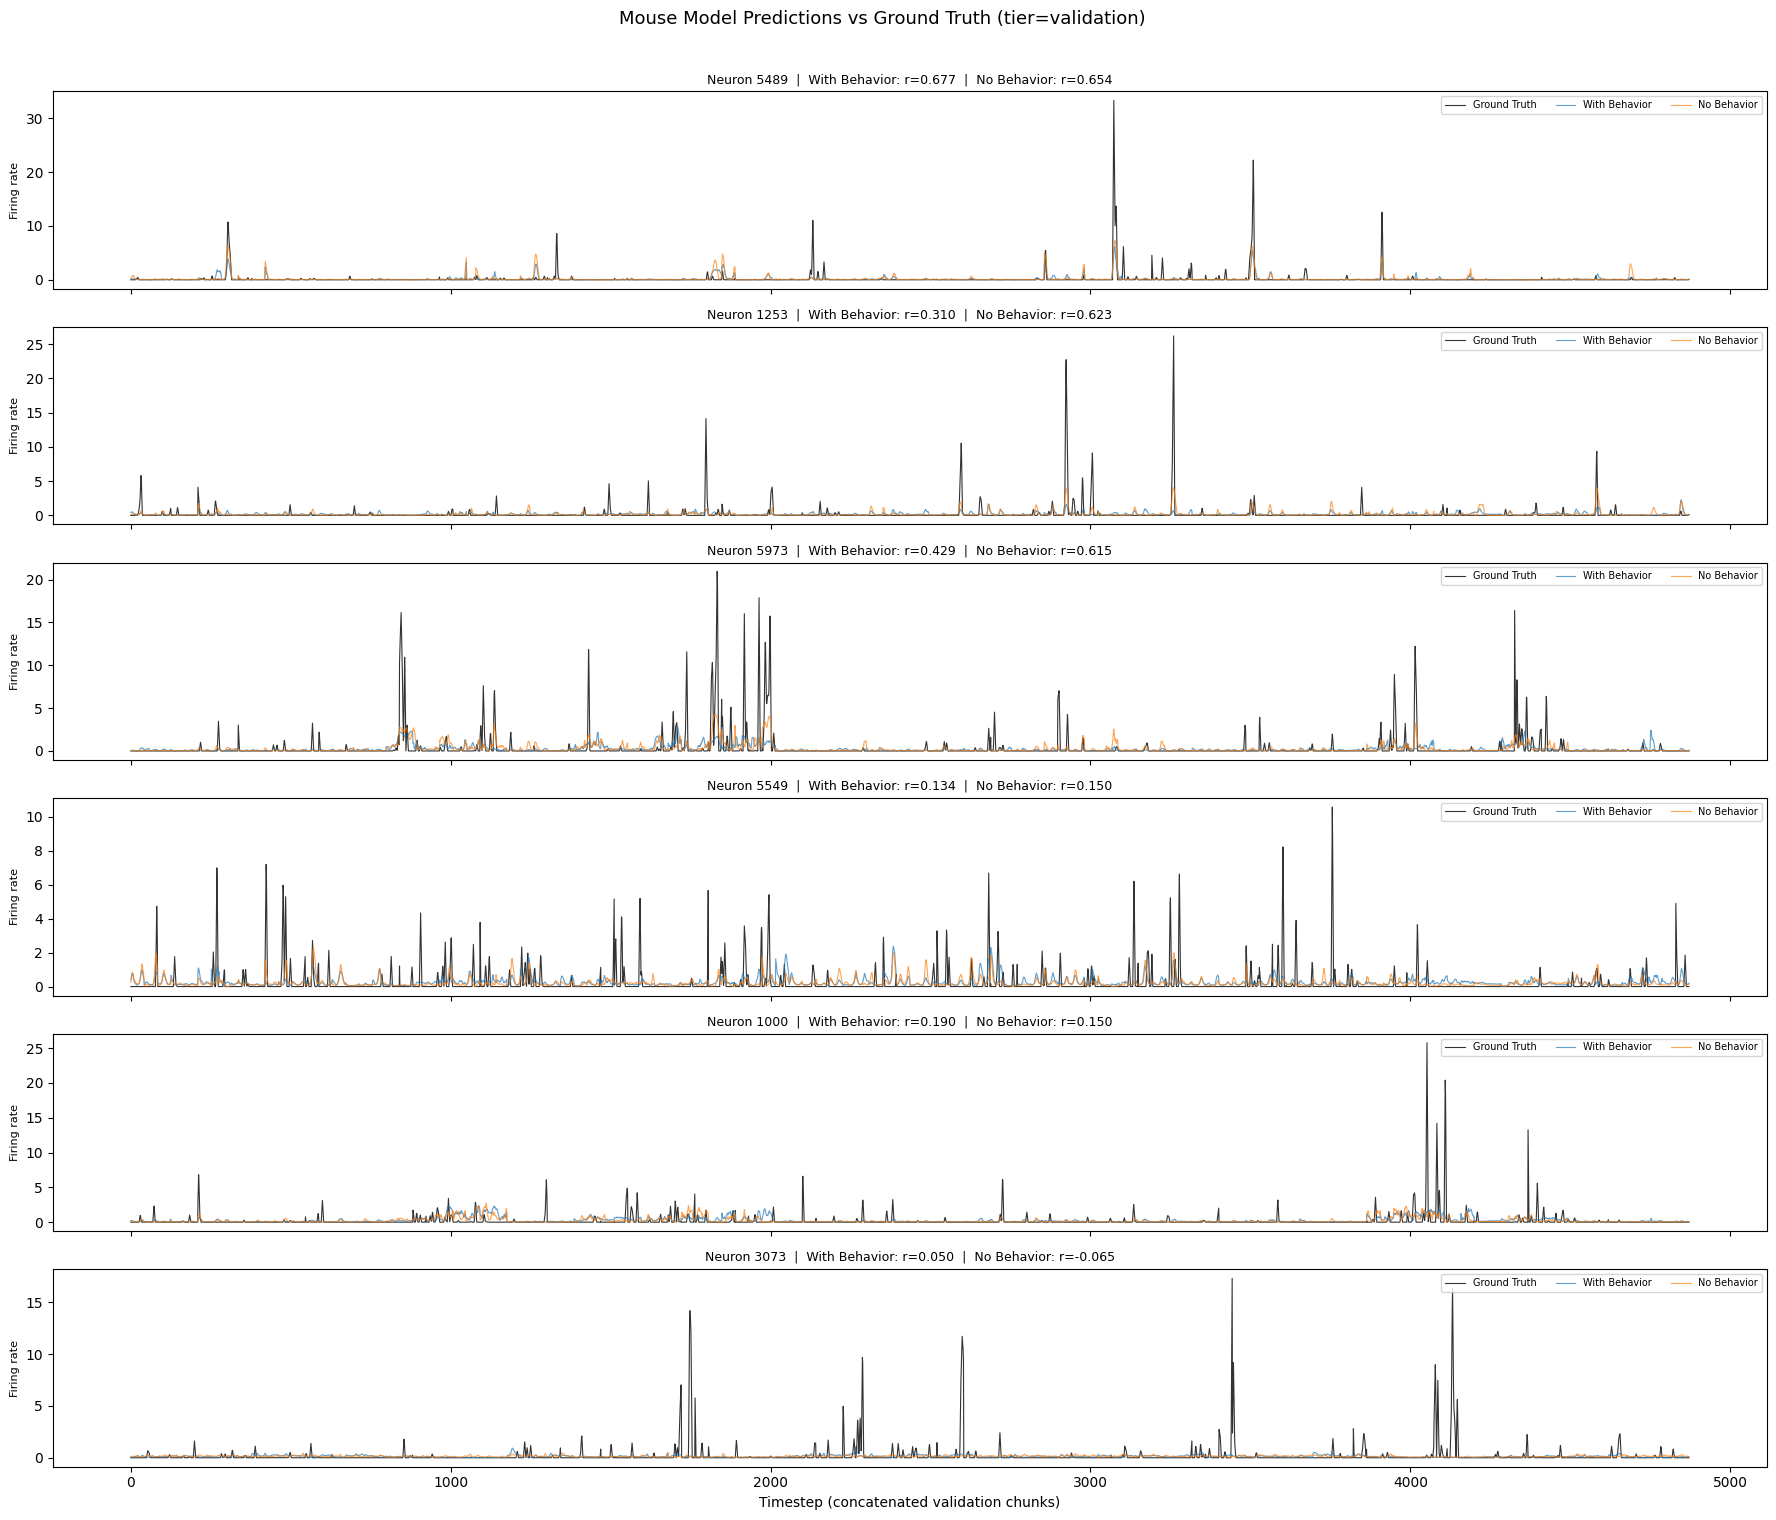

In [8]:
fig_traces = plot_traces(
    target_mouse,
    outputs_dict={'With Behavior': pred_a, 'No Behavior': pred_b},
    neuron_indices=selected,
    per_neuron_corrs_dict={'With Behavior': corr_a, 'No Behavior': corr_b},
    suptitle=f'Mouse Model Predictions vs Ground Truth (tier={TIER})',
    time_axis_label='Timestep (concatenated validation chunks)',
)

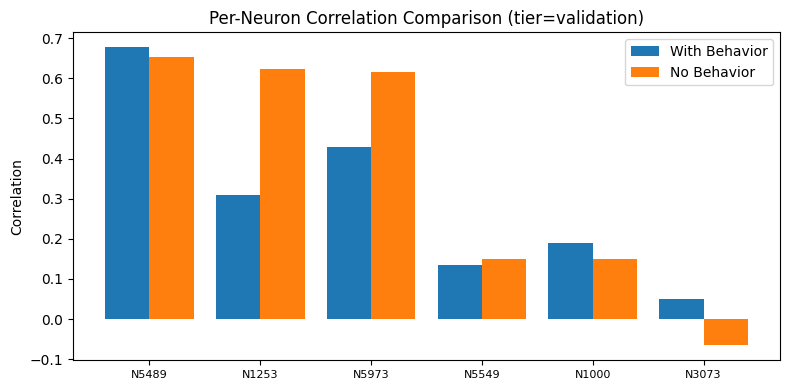

In [9]:
fig_bars = plot_correlation_bars(
    selected,
    {'With Behavior': corr_a, 'No Behavior': corr_b},
    title=f'Per-Neuron Correlation Comparison (tier={TIER})',
)

## Correlation Distribution (All Neurons)

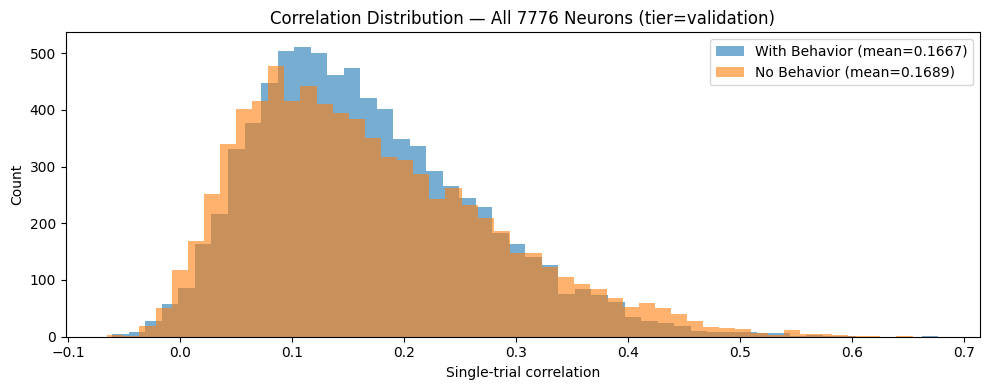

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(corr_a, bins=50, alpha=0.6, label=f'With Behavior (mean={corr_a.mean():.4f})', color='#1f77b4')
ax.hist(corr_b, bins=50, alpha=0.6, label=f'No Behavior (mean={corr_b.mean():.4f})', color='#ff7f0e')
ax.set_xlabel('Single-trial correlation')
ax.set_ylabel('Count')
ax.set_title(f'Correlation Distribution — All {nn_b} Neurons (tier={TIER})')
ax.legend()
plt.tight_layout()
plt.show()

---

# Part 2: Mozaik Synthetic Data Model

## Load Mozaik Data

In [11]:
mozaik_session_path = '/mnt/vast-react/projects/neural_foundation_model/MOZAIK/mozaik_data_dynamic26872-17-20-Video-mozaik-trial_new1/'
mozaik_session_name = 'mozaik_data_dynamic26872-17-20-Video-mozaik-trial_new1'

cfg_moz = deepcopy(DEFAULT_CONFIG)

# Remove behavior modalities
del cfg_moz['dataset']['modality_config']['eye_tracker']
del cfg_moz['dataset']['modality_config']['treadmill']
cfg_moz['dataset']['out_keys'] = ['screen', 'responses', 'timestamps']

# Response config: SpikeInterpolator
cfg_moz['dataset']['modality_config']['responses']['sampling_rate'] = 30
cfg_moz['dataset']['modality_config']['responses']['chunk_size'] = 60
cfg_moz['dataset']['modality_config']['responses']['interpolation'] = {
    'interpolation_window': 1.0 / 30,
    'interpolation_align': 'left',
}
cfg_moz['dataset']['modality_config']['responses']['transforms']['normalization'] = False
cfg_moz['dataset']['modality_config']['responses']['filters'] = {}

# Screen config
cfg_moz['dataset']['modality_config']['screen']['sampling_rate'] = 30
cfg_moz['dataset']['modality_config']['screen']['chunk_size'] = 60
cfg_moz['dataset']['modality_config']['screen']['transforms']['normalization'] = {
    'mean': 113, 'std': 59,
}
cfg_moz['dataset']['modality_config']['screen']['interpolation']['rescale'] = True
cfg_moz['dataset']['modality_config']['screen']['interpolation']['rescale_size'] = [144, 256]
cfg_moz['dataset']['modality_config']['screen']['transforms']['Resize']['size'] = [144, 256]
cfg_moz.dataset.modality_config.screen.valid_condition = {'tier': TIER}
cfg_moz['dataset']['modality_config']['screen']['sample_stride'] = 60

cfg_moz['dataloader']['batch_size'] = 4
cfg_moz['dataloader']['prefetch_factor'] = 2
cfg_moz['dataloader']['num_workers'] = 4
cfg_moz['dataloader']['shuffle'] = False
cfg_moz['dataloader']['pin_memory'] = False

mozaik_dl = get_multisession_dataloader([mozaik_session_path], cfg_moz)
mozaik_data_key = mozaik_session_name.split('dynamic')[-1].split('-Video')[0]
print(f'Mozaik data key: {mozaik_data_key}')

# Verify batch shapes
sample_batch_moz = next(iter(list(mozaik_dl.loaders.values())[0]))
for k, v in sample_batch_moz.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape}')

No metadata file found at /mnt/vast-react/projects/neural_foundation_model/MOZAIK/mozaik_data_dynamic26872-17-20-Video-mozaik-trial_new1/meta.json
Mozaik data key: 26872-17-20
  responses: torch.Size([4, 60, 37500])
  screen: torch.Size([4, 1, 60, 144, 256])


## Load Mozaik Model & Run Predictions

In [12]:
model_c, dk_c, nn_c = load_model(
    '../test_training/single_session_mozaik_26872_no_beh/best.pth',
    core_dict_1ch, readout_dict,
)

print('\n--- Model C (Mozaik, no behavior) ---')
target_mozaik, pred_c = get_all_predictions(
    model_c, mozaik_dl, dk_c, behavioral_modulation=False,
)

print(f'\nTarget shape: {target_mozaik.shape}')
print(f'Pred C shape: {pred_c.shape}')

Loaded ./test_training/single_session_mozaik_26872_no_beh/best.pth -- data_key=26872-17-20, n_neurons=37500

--- Model C (Mozaik, no behavior) ---


Predicting: 100%|██████████| 2/2 [02:19<00:00, 69.76s/it]

Collected 336 timesteps, 37500 neurons

Target shape: (336, 37500)
Pred C shape: (336, 37500)


## Select Mozaik Neurons

In [13]:
# Set to a list of ints to manually pick neurons
manual_mozaik_neuron_indices = None

auto_mozaik_indices, corr_c = select_neurons(target_mozaik, pred_c, n_best=3, n_mid=2, n_low=1)

selected_mozaik = manual_mozaik_neuron_indices if manual_mozaik_neuron_indices is not None else auto_mozaik_indices

print(f'\nSelected Mozaik neurons: {selected_mozaik}')
print(f'{"Neuron":>8s}  {"Corr":>10s}')
for idx in selected_mozaik:
    print(f'{idx:>8d}  {corr_c[idx]:>10.4f}')

Selected 6 neurons:
  Neuron 2971: corr = 0.4804
  Neuron 12337: corr = 0.4687
  Neuron 18770: corr = 0.4630
  Neuron 6652: corr = 0.1797
  Neuron 27880: corr = 0.1797
  Neuron 24153: corr = -0.0392

Selected Mozaik neurons: [2971, 12337, 18770, 6652, 27880, 24153]
  Neuron        Corr
    2971      0.4804
   12337      0.4687
   18770      0.4630
    6652      0.1797
   27880      0.1797
   24153     -0.0392


## Mozaik Model: Prediction vs Ground Truth Traces

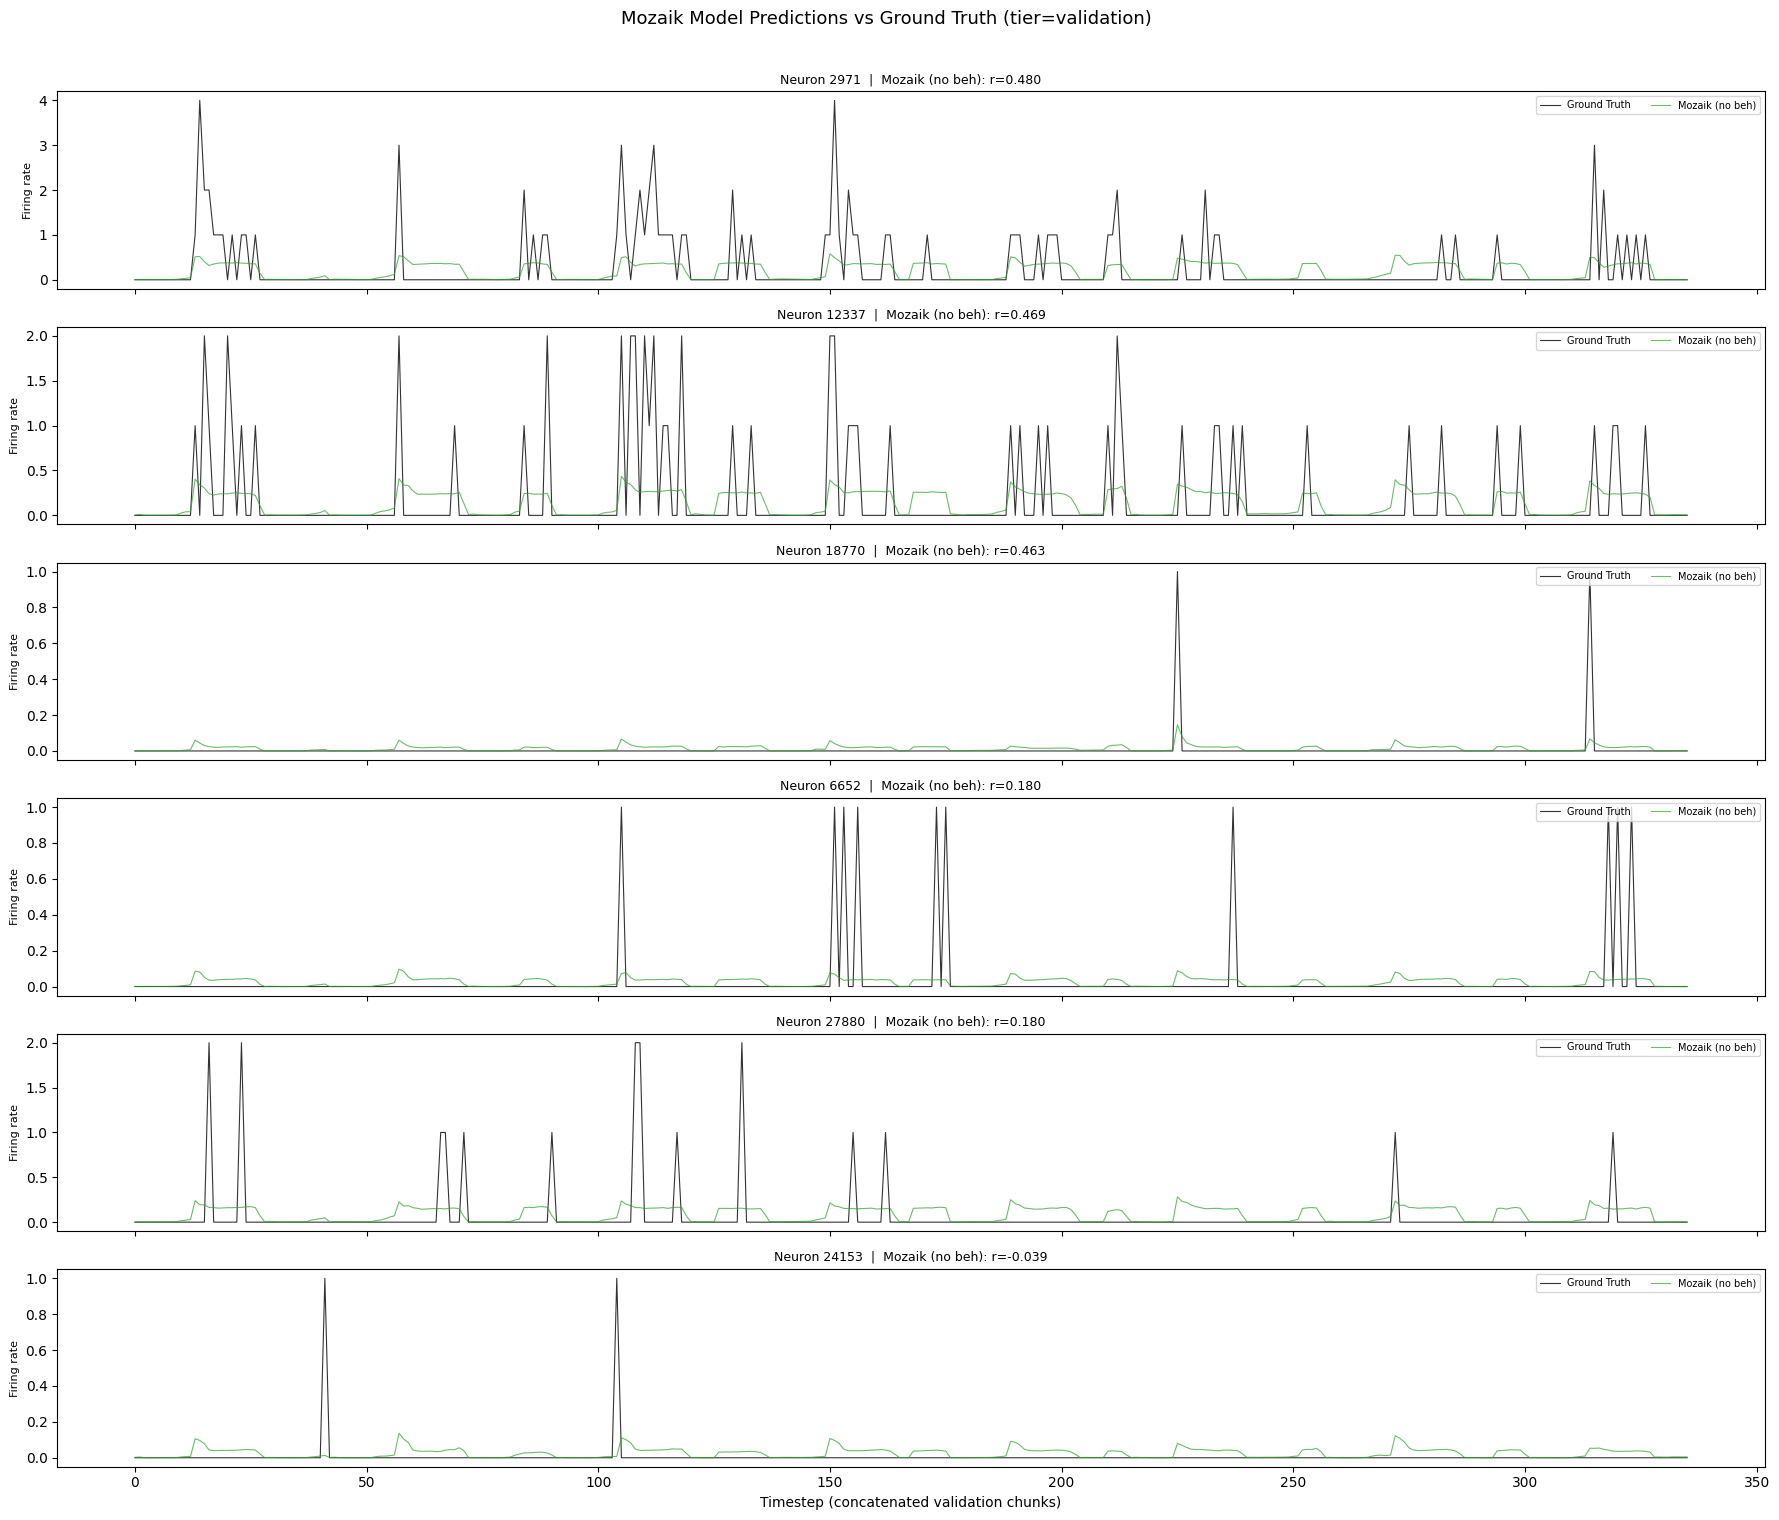

In [14]:
fig_moz_traces = plot_traces(
    target_mozaik,
    outputs_dict={'Mozaik (no beh)': pred_c},
    neuron_indices=selected_mozaik,
    per_neuron_corrs_dict={'Mozaik (no beh)': corr_c},
    suptitle=f'Mozaik Model Predictions vs Ground Truth (tier={TIER})',
    time_axis_label='Timestep (concatenated validation chunks)',
)

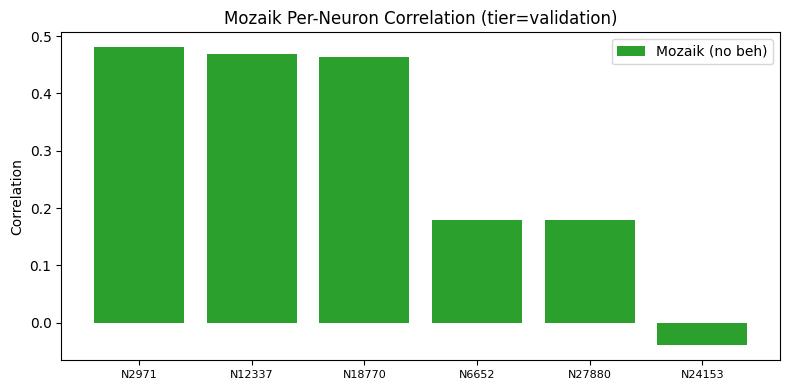

In [15]:
fig_moz_bars = plot_correlation_bars(
    selected_mozaik,
    {'Mozaik (no beh)': corr_c},
    title=f'Mozaik Per-Neuron Correlation (tier={TIER})',
)

## Mozaik Correlation Distribution (All Neurons)

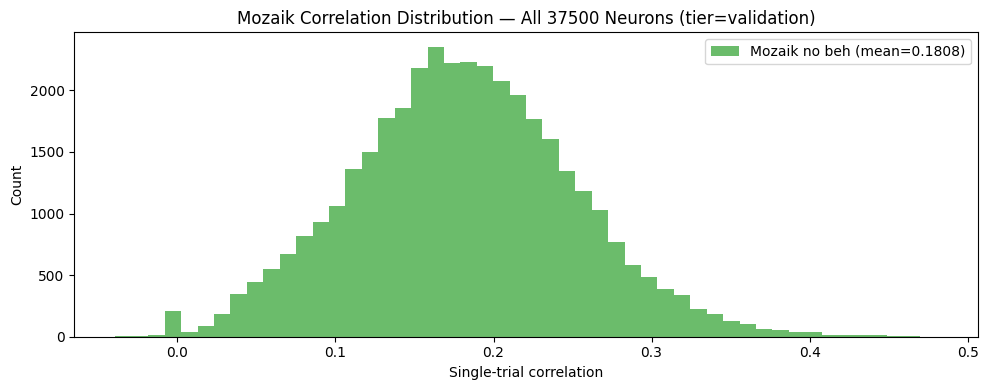


Mozaik mean correlation: 0.1808
Mouse mean correlation (with beh): 0.1667
Mouse mean correlation (no beh): 0.1689


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(corr_c, bins=50, alpha=0.7, label=f'Mozaik no beh (mean={corr_c.mean():.4f})', color='#2ca02c')
ax.set_xlabel('Single-trial correlation')
ax.set_ylabel('Count')
ax.set_title(f'Mozaik Correlation Distribution — All {nn_c} Neurons (tier={TIER})')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nMozaik mean correlation: {corr_c.mean():.4f}')
print(f'Mouse mean correlation (with beh): {corr_a.mean():.4f}')
print(f'Mouse mean correlation (no beh): {corr_b.mean():.4f}')